In [1]:
from huggingface_hub import logout, notebook_login
logout()
notebook_login()

Not logged in!


# 1. Data Loading Methods

Run the cells below to get data retrieval functions:

- `sample_data(ds)`: randomly obtain `N` samples from dataset, `ds`
- `sample_with_outliers(ds, featurizer)`: uses data-specific `featurizer` to obtain total, `N` (`N_OUTLIERS` + remaining sampling), samples from dataset, `ds`
- `sample_n_per_class(ds, class_column)`: obtain `N` samples of *each* class in `class_column` from dataset, `ds`

Non-optional parameters will be defined in subsequent blocks that require these functions.

## Direct Random Sampling

In [29]:
from datasets import IterableDataset

def sample_data(
        ds: IterableDataset,
        n: int = None,
        seed: int = None,
        buffer_size: int = None
        ) -> Dataset:

    if n is None:
        n = N

    if seed is None:
        seed = SEED

    if buffer_size is None:
        buffer_size = BUFFER_SIZE

    return ds.shuffle(seed = seed,
                      buffer_size = buffer_size).take(n)

## Outlier-prioritized Sampling

In [28]:
from __future__ import annotations

from collections.abc import Callable, Mapping
from typing import Any

import numpy as np
from datasets import Dataset, IterableDataset
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from functools import partial

Row = Mapping[str, Any]
Featurizer = Callable[[Row], np.ndarray | None]

def sample_with_outliers(
        ds: IterableDataset,
        featurize: Featurizer,
        pool_size: int = None,
        n: int = None,
        n_outliers: int = None,
        seed: int = None,
        buffer_size: int = None,
        n_trees: int = None,
        n_pca: int = None,
        debug: bool = None,
        ) -> Dataset:

    if pool_size is None:
        pool_size = POOL_SIZE

    if n is None:
        n = N

    if n_outliers is None:
        n_outliers = N_OUTLIERS

    if n_trees is None:
        n_trees = N_TREES

    if seed is None:
        seed = SEED

    if buffer_size is None:
        buffer_size = pool_size

    if n_pca is None:
        n_pca = N_PCA

    features = getattr(ds, "features", None)

    ds = ds.shuffle(
        seed = seed,
        buffer_size = buffer_size,
    )

    pool = []
    feature_vectors = []

    for row in ds:
        vector = featurize(row)

        if vector is None:
            continue

        pool.append(dict(row))
        feature_vectors.append(
            np.asarray(
                vector,
                dtype=np.float32,
            ).reshape(-1)
        )

        if len(pool) >= pool_size:
            break

    X = np.stack(feature_vectors)

    np.nan_to_num(
        X,
        copy = False,
        nan = 0.0,
        posinf = 0.0,
        neginf = 0.0,
    )

    X = StandardScaler().fit_transform(X)

    pca_components = min(
        n_pca,
        X.shape[0] - 1,
        X.shape[1],
    )

    X = PCA(
        n_components = pca_components,
        random_state = seed,
    ).fit_transform(X)

    model = IsolationForest(
        n_estimators = n_trees,
        random_state = seed,
        n_jobs = -1,
    )

    model.fit(X)
    scores = -model.score_samples(X)

    order = np.argsort(scores)[::-1]
    outlier_idx = order[:n_outliers]

    remaining_idx = np.setdiff1d(
        np.arange(len(pool)),
        outlier_idx,
        assume_unique=True,
    )

    rng = np.random.default_rng(seed)

    random_idx = rng.choice(
        remaining_idx,
        size=n - n_outliers,
        replace = False,
    )

    selected_idx = np.concatenate([
        outlier_idx,
        random_idx,
    ])

    rng.shuffle(selected_idx)

    selected_rows = [
        pool[int(index)]
        for index in selected_idx
    ]

    sub = Dataset.from_list(
        selected_rows,
        features=features,
    )

    if debug:
        outlier_set = set(outlier_idx.tolist())

        is_outlier = [
            int(index) in outlier_set
            for index in selected_idx
        ]

        selected_scores = [
            float(scores[int(index)])
            for index in selected_idx
        ]

        sub = sub.add_column(
            "is_outlier",
            is_outlier,
        )

        sub = sub.add_column(
            "anomaly_score",
            selected_scores,
        )

        outlier_scores = scores[outlier_idx]

        print(
            f"""
pool_size_actual -> {len(pool)}
selected_count -> {len(sub)}
outlier_count -> {len(outlier_idx)}
random_count -> {len(random_idx)}
min_outlier_score -> {outlier_scores.min() if len(outlier_scores) else None}
max_outlier_score -> {outlier_scores.max() if len(outlier_scores) else None}
mean_outlier_score -> {outlier_scores.mean() if len(outlier_scores) else None}
            """
        )

    return sub

### Data-specific helpers

In [24]:
from __future__ import annotations

from collections.abc import Mapping, Sequence
from typing import Any

import numpy as np

#### DESI

In [25]:
def featurize_desi(
        row: Mapping[str, Any],
        n_bins: int = 256,
        ) -> np.ndarray:

    spectrum = row["spectrum"]

    flux = np.asarray(spectrum["flux"], dtype = np.float32)
    ivar = np.asarray(spectrum["ivar"], dtype = np.float32)
    mask = np.asarray(spectrum["mask"], dtype = bool)

    valid = (
        np.isfinite(flux)
        & np.isfinite(ivar)
        & (ivar > 0)
        & (~mask)
    )

    if not valid.any():
        return np.zeros(n_bins, dtype=np.float32)

    scale = float(np.median(np.abs(flux[valid])))
    normalized_flux = flux / scale

    n_pixels = len(flux)
    pixel_indices = np.arange(n_pixels, dtype = np.int64)

    bin_ids = np.minimum(
        pixel_indices * n_bins // n_pixels,
        n_bins - 1,
    )

    weights = np.where(valid, ivar, 0.0)

    weighted_flux = np.where(
        valid,
        normalized_flux * ivar,
        0.0,
    )

    numerator = np.bincount(
        bin_ids,
        weights = weighted_flux,
        minlength = n_bins,
    )

    denominator = np.bincount(
        bin_ids,
        weights = weights,
        minlength = n_bins,
    )

    features = np.divide(
        numerator,
        denominator,
        out = np.zeros(n_bins, dtype = np.float64),
        where = denominator > 0,
    )

    return features.astype(np.float32)

#### Plasticc

In [26]:
def featurize_plasticc(
        row: Row,
        bands: Sequence[Any] = ("u", "g", "r", "i", "z", "Y"),
        min_obs: int | None = 20,
        ) -> np.ndarray | None:

    lightcurve = row["lightcurve"]

    time = np.asarray(lightcurve["time"], dtype = np.float64)
    flux = np.asarray(lightcurve["flux"], dtype = np.float64)
    flux_error = np.asarray(lightcurve["flux_err"], dtype = np.float64)
    band = np.asarray(lightcurve["band"])

    valid = (
        np.isfinite(time)
        & np.isfinite(flux)
        & np.isfinite(flux_error)
        & (flux_error > 0)
    )

    time = time[valid]
    flux = flux[valid]
    flux_error = flux_error[valid]
    band = band[valid]

    n_band_features = 13
    output_size = len(bands) * n_band_features + 4
    snr = flux / flux_error

    scale = float(np.max(np.abs(flux)))

    feature_blocks = []

    for band_name in bands:
        band_mask = band == band_name

        if np.count_nonzero(band_mask) < 2:
            empty = np.zeros(n_band_features, dtype = np.float32)
            feature_blocks.append(empty)

            continue

        band_time = time[band_mask]
        band_flux = flux[band_mask]
        band_snr = snr[band_mask]

        order = np.argsort(band_time)

        band_time = band_time[order]
        band_flux = band_flux[order]
        band_snr = band_snr[order]

        scaled_flux = band_flux / scale

        mean_flux = float(np.mean(scaled_flux))
        std_flux = float(np.std(scaled_flux))

        if std_flux > 0:
            standardized_flux = (scaled_flux - mean_flux) / std_flux
            skewness = float(np.mean(standardized_flux ** 3))
            kurtosis = float(np.mean(standardized_flux ** 4))
        else:
            skewness = 0.0
            kurtosis = 0.0

        peak_index = int(np.argmax(np.abs(band_snr)))

        maximum_flux = float(np.max(scaled_flux))
        minimum_flux = float(np.min(scaled_flux))
        fraction_near_peak = float(np.mean(scaled_flux > 0.5 * maximum_flux))

        band_features = np.array(
            [
                np.log1p(len(band_flux)),

                maximum_flux,
                minimum_flux,
                maximum_flux - minimum_flux,

                mean_flux,
                std_flux,
                skewness,
                kurtosis,

                float(np.max(np.abs(band_snr))),
                float(np.median(np.abs(band_snr))),

                float(band_time[peak_index] - band_time[0]),
                float(band_time[-1] - band_time[peak_index]),

                fraction_near_peak,
            ],
            dtype = np.float32
        )

        feature_blocks.append(band_features)

    global_features = np.array(
        [
            np.log10(scale + 1.0),
            np.log1p(len(flux)),
            float(time.max() - time.min()),
            float(len(np.unique(band))),
        ],
        dtype = np.float32
    )

    feature_blocks.append(global_features)

    return np.concatenate(feature_blocks)

## Obtain N samples from each class

In [30]:
from collections import Counter, defaultdict
from random import Random
from typing import Any, Hashable

from datasets import Dataset, IterableDataset

def sample_n_per_class(
        ds: IterableDataset,
        class_column: str,
        n: int = None,
        seed: int = None,
        buffer_size: int = None,
        debug: bool = None
        ) -> Dataset:

    if n is None:
        n = N

    if seed is None:
        seed = SEED

    if buffer_size is None:
        buffer_size = BUFFER_SIZE

    features = ds.features

    ds = ds.shuffle(
        seed = seed,
        buffer_size = buffer_size,
    )

    rng = Random(seed)

    counter: Counter[Hashable] = Counter()
    reservoirs: dict[
        Hashable,
        list[dict[str, Any]]
    ] = defaultdict(list)

    rows_scanned = 0

    for row in ds:
        rows_scanned += 1

        label = row[class_column]
        counter[label] += 1

        class_seen = counter[label]
        reservoir = reservoirs[label]

        if len(reservoir) < n:
            reservoir.append(dict(row))
            continue

        replacement_index = rng.randrange(class_seen)

        if replacement_index < n:
            reservoir[replacement_index] = dict(row)

    classes = sorted(
        reservoirs,
        key = lambda value: (
            type(value).__name__,
            repr(value),
        ),
    )

    selected_rows = [
        row
        for label in classes
        for row in reservoirs[label]
    ]

    rng.shuffle(selected_rows)

    sub = Dataset.from_list(
        selected_rows,
        features = features,
    )

    selected_counts = {
        label: len(reservoirs[label])
        for label in classes
    }

    underfilled_classes = {
        label: counter[label]
        for label in classes
        if counter[label] < n
    }

    if debug is True:
        print(
            f"""
'classes' -> {classes}
'number_of_classes' -> {len(classes)}
'observed_counts' -> {dict(counter)}
'selected_counts' -> {selected_counts}
'underfilled_classes' -> {underfilled_classes}
'total_rows_scanned' -> {rows_scanned}
            """
            )

    return sub

# 2. HF MMU Data

Define `ds`: run whichever data you want to use. I hope I was able to generalize the functions above to work with whichever dataset.

The returned dataset can be called with `ds` in subsequent blocks.

## DESI

In [ ]:
from datasets import load_dataset, Dataset

NAME = "desi"
ds = load_dataset("MultimodalUniverse/desi",
                    split = "train",
                    streaming = True)

## TESS

In [ ]:
from datasets import load_dataset, Dataset

NAME = "tess"
ds = load_dataset("MultimodalUniverse/tess",
                    split = "train",
                    streaming = True)

README.md:   0%|          | 0.00/3.45k [00:00<?, ?B/s]

## PLAsTiCC

In [5]:
from datasets import load_dataset, Dataset

NAME = "plasticc"
ds = load_dataset("MultimodalUniverse/plasticc",
                    split = "train",
                    streaming = True)

README.md:   0%|          | 0.00/4.90k [00:00<?, ?B/s]

# 3. Define Hyperparameters and Obtain Data

Using `ds`, obtain `N` data points (with other param settings) using specified functions from step 1.

## Sampling

In [31]:
N = 100
SEED = 111
BUFFER_SIZE = 1000

sub = sample_data(ds)

## Outliers

Since the definition of an "outlier" depends on the data type, this step can't really be generalized, and a `featurizer` should be selected.

In [32]:
# featurize_desi, featurize_plasticc

MIN_OBS = 20
BANDS = ("u", "g", "r", "i", "z", "Y")

featurize_func = partial(featurize_plasticc, bands = BANDS, min_obs = MIN_OBS)

In [19]:
N = 100 # total
N_OUTLIERS = 50 # number of outliers
SEED = 111
BUFFER_SIZE = 2000 # search space
N_TREES = 300
N_PCA = 20

sub = sample_with_outliers(
    ds = ds,
    featurize = featurize_func
    debug = True, # prints details
)


pool_size_actual -> 2000
selected_count -> 100
outlier_count -> 50
random_count -> 50
min_outlier_score -> 0.5263685877817867
max_outlier_score -> 0.6580301323894444
mean_outlier_score -> 0.5628497022208766
            


## N Per Class

In [33]:
N = 20 # N per class
SEED = 111
BUFFER_SIZE = 1000

sub = sample_n_per_class(
    ds = ds,
    class_column = "obj_type"
)

## 3.1 (optional) Download light curve data

`download_ds(cols, ds, str_append)`: saves `cols` from `ds` as `parquet` format with `str_append` at the end.

In [ ]:
from typing import List
from datasets import Dataset

# usage:
# download_ds(["lightcurve"], ds_tess, "with_outliers")
# -> will save to "tess_100_with_outliers.parquet"
def download_ds(
        cols: List[str],
        ds: Dataset,
        str_append: str = ""):

    part = ds.select_columns(cols)

    if str_append != "":
        str_append = "_" + str_append

    part.to_parquet(f"{NAME}_{N}{str_append}")

# 4. Analysis

## Data class distribution

### Light curves

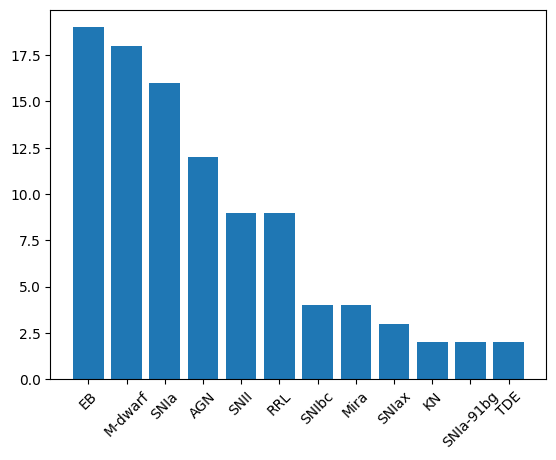

In [20]:
import matplotlib.pyplot as plt

df = sub.select_columns(["obj_type"]).to_pandas()
counts = df.value_counts()

x, y = [], []

for k, v in counts.items():
    x += [k[0]]
    y += [v]

plt.bar(x, y)
plt.xticks(rotation = 45)
plt.show()